<a href="https://atap.edu.au"><img src="https://www.atap.edu.au/atap-logo.png" width="125" height="50" align="right"></a>
# ATAP: TopSBM

TopSBM is a topic modelling approach that leverages a bipartite network of documents and terms and finding a hierarchy of blocks (or clusters) within the two types.

Australian Text Analytics Platform (ATAP) is an open source environment that provides researchers with tools and training for analysing, processing, and exploring text. ATAP: TopSBM is an effort to integrate the TopSBM approach developed by E.G. Altman et al which focuses on analysing and exploring your text.

**References**:
1. TopSBM: Topic Models based on Stochastic Block Models - https://topsbm.github.io/
2. ATAP: Australian Text Analytics Platform - https://www.atap.edu.au/
   

## Demo
This notebook is a demo of using TopSBM and integrates with `atap_corpus` from ATAP.

It first builds an ATAP Corpus and assign a 'title' as metadata and then compute a document-term-matrix DTM. <br>The DTM will be used as input to build the TopSBM network which the model will be fitted against. The 'title' metadata is used as label for the documents.

Then, wrap the model and corpus with the ATAP wrapper allows you to integrate your results with ATAP Corpus including at the end a download link for your Corpus with your results for re-use. You can then carry it across to another ATAP tool notebook available on our [website](https://www.atap.edu.au/) for further exploration or analysis.

In [1]:
import sys
sys.path.append("../atap_corpus/")
sys.path.append("../../hSBM_Topicmodel/")

In [2]:
import sbmtm

In [3]:
import atap_corpus

/home/ega/anaconda3/envs/gt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Choose data

Default

In [ ]:
import pandas as pd
# documents
with open('assets/corpus.txt', 'r', encoding='utf-8') as h:
    lines = h.readlines() 
df = pd.DataFrame(lines, columns=['document'])

# meta - title
with open('assets/titles.txt', 'r', encoding='utf-8') as h:
    titles = [l.rstrip() for l in h.readlines()]
df['title'] = titles
df.head(3)

In [ ]:
# documents
with open('../dataTutorial/constitutions-texts.txt', 'r', encoding='utf-8') as h:
    lines = h.readlines() 
df = pd.DataFrame(lines, columns=['document'])

# meta - title
with open('../dataTutorial/constitutions-titles.txt', 'r', encoding='utf-8') as h:
    titles = [l.rstrip() for l in h.readlines()]
df['title'] = titles
df.head(3)

### Alternative: Upload Corpus
You may choose to upload the pre-built `demo_corpus.zip` which will be the exact corpus built from the previous cells.

In [ ]:
# alternatively: upload demo_corpus.zip - which is the corpus built before.
from atap_corpus.utils import corpus_uploader

finp, corpora = corpus_uploader()
finp

In [ ]:
corpus = corpora.items()[-1]   # retrieve last uploaded corpus
dtm_name = list(corpus.dtms.keys())[0] # retrieve the name of the first DTM (only has one)
f"Corpus <name: {corpus.name}   size: {len(corpus)} documents>"

## Generate corpus

In [ ]:
from atap_corpus import Corpus

corpus = Corpus.from_dataframe(df, col_doc='document', name='topsbm')
f"Corpus <name: {corpus.name}   size: {len(corpus)} documents>"

In [ ]:
# create your document-term-matrix
dtm_name = 'tokens'                               # name of your DTM
tokeniser_func = lambda doc: doc.split()          # how you define each 'term' in the DTM from each document. (Here, it is whitespace delimited)

corpus.add_dtm_from_docs(tokeniser_func=tokeniser_func, name=dtm_name)
f"Created DTM: {corpus.dtms[dtm_name]}"

# TopSBM: `make_graph()` and `fit()`

In [5]:
import sbmtm as topsbm
import time

In [ ]:
start = time.time()

model = topsbm.sbmtm()
model.make_graph(corpus.dtms['tokens'].to_lists_of_terms(), corpus['title'].tolist())

end = time.time()
print(end - start)

model.fit()

end2 = time.time()
print(end2 - end)

# Explore results

In [6]:
model = topsbm.sbmtm()
model.load_model("results/constitutions-fitted.pickle")

## Visualise the inferred hierarchical blocks

In [7]:
from atap_wrapper import visualise_blocks 

vis_doc, vis_word = visualise_blocks(model, kind='collapsible-tree')

/home/ega/gitRepos/ATAP/topsbm/../../hSBM_Topicmodel/sbmtm.py:571: RuntimeWarning: invalid value encountered in divide
  p_td_d = (n_db/np.sum(n_db,axis=1)[:,np.newaxis]).T
/home/ega/gitRepos/ATAP/topsbm/../../hSBM_Topicmodel/sbmtm.py:577: RuntimeWarning: invalid value encountered in divide
  p_tw_d = (n_dbw/np.sum(n_dbw,axis=1)[:,np.newaxis]).T


AssertionError: Expecting only 1 root

In [ ]:
vis_doc

In [ ]:
vis_word

## ATAP wrapper: Download 

Wrap your model and corpus with atap and then call serialise on the wrapper.
This is a custom wrapper for TopSBM only.

In [8]:
from atap_wrapper import wrap

wrapped = wrap(model, corpus, used_dtm=dtm_name) # dtm_name is the name of the dtm you've used earlier to build and fit the model.
wrapped.download()

NameError: name 'corpus' is not defined

# Usual Analayis

In [9]:
model.print_overview()

AttributeError: 'sbmtm' object has no attribute 'print_overview'

In [10]:
model.topics(l=2,n=10)

{0: [('the', 0.11131108248560817),
  ('of', 0.07639251014028689),
  ('and', 0.03359613048343589),
  ('to', 0.03159485079191483),
  ('in', 0.023892977575332208),
  ('a', 0.022743416212620465),
  ('or', 0.02228702109048133),
  ('shall', 0.01833355413179695),
  ('be', 0.017096847843550665),
  ('by', 0.01494547217516553)],
 1: [('chamber', 0.17445876505770364),
  ('municipalities', 0.06166287591609806),
  ('sudan', 0.052396596748378405),
  ('peoples', 0.0450678123157274),
  ('islamic', 0.034537949625136885),
  ('southern', 0.030999915761098475),
  ('grand', 0.026619492881812822),
  ('sec', 0.025861342768090306),
  ('june', 0.025187431555892512),
  ('prince', 0.021396680987279926)],
 2: [('subsection', 0.034046106291092275),
  ('proceedings', 0.025336894433292966),
  ('speaker', 0.02311950144600565),
  ('appeal', 0.022483590738928243),
  ('relation', 0.014907958837223447),
  ('officer', 0.013641667081391041),
  ('fund', 0.012541265075231001),
  ('budget', 0.011457452044038198),
  ('deputies

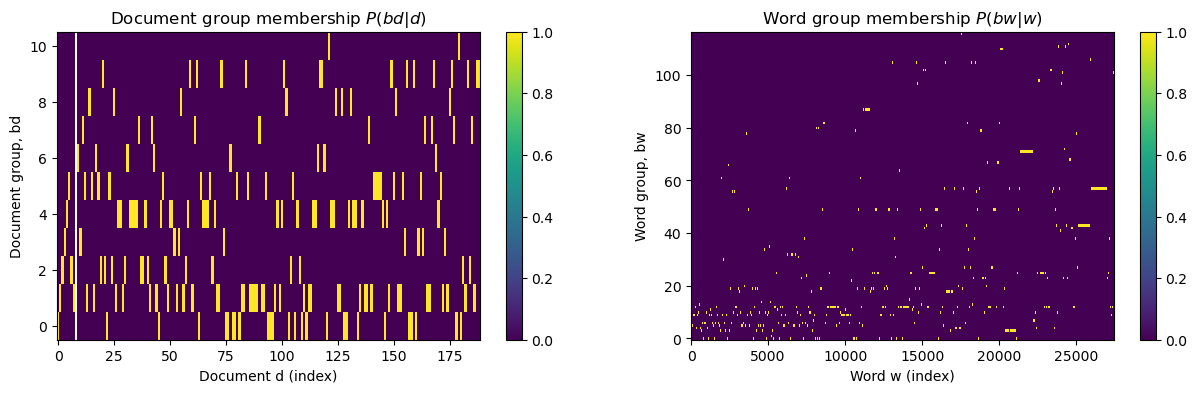

In [15]:
import pylab as plt
p_td_d,p_tw_w = model.group_membership(l=1)

plt.figure(figsize=(15,4))
plt.subplot(121)
plt.imshow(p_td_d,origin='lower',aspect='auto',interpolation='none')
plt.title(r'Document group membership $P(bd | d)$')
plt.xlabel('Document d (index)')
plt.ylabel('Document group, bd')
plt.colorbar()

plt.subplot(122)
plt.imshow(p_tw_w,origin='lower',aspect='auto',interpolation='none')
plt.title(r'Word group membership $P(bw | w)$')
plt.xlabel('Word w (index)')
plt.ylabel('Word group, bw')
plt.colorbar()

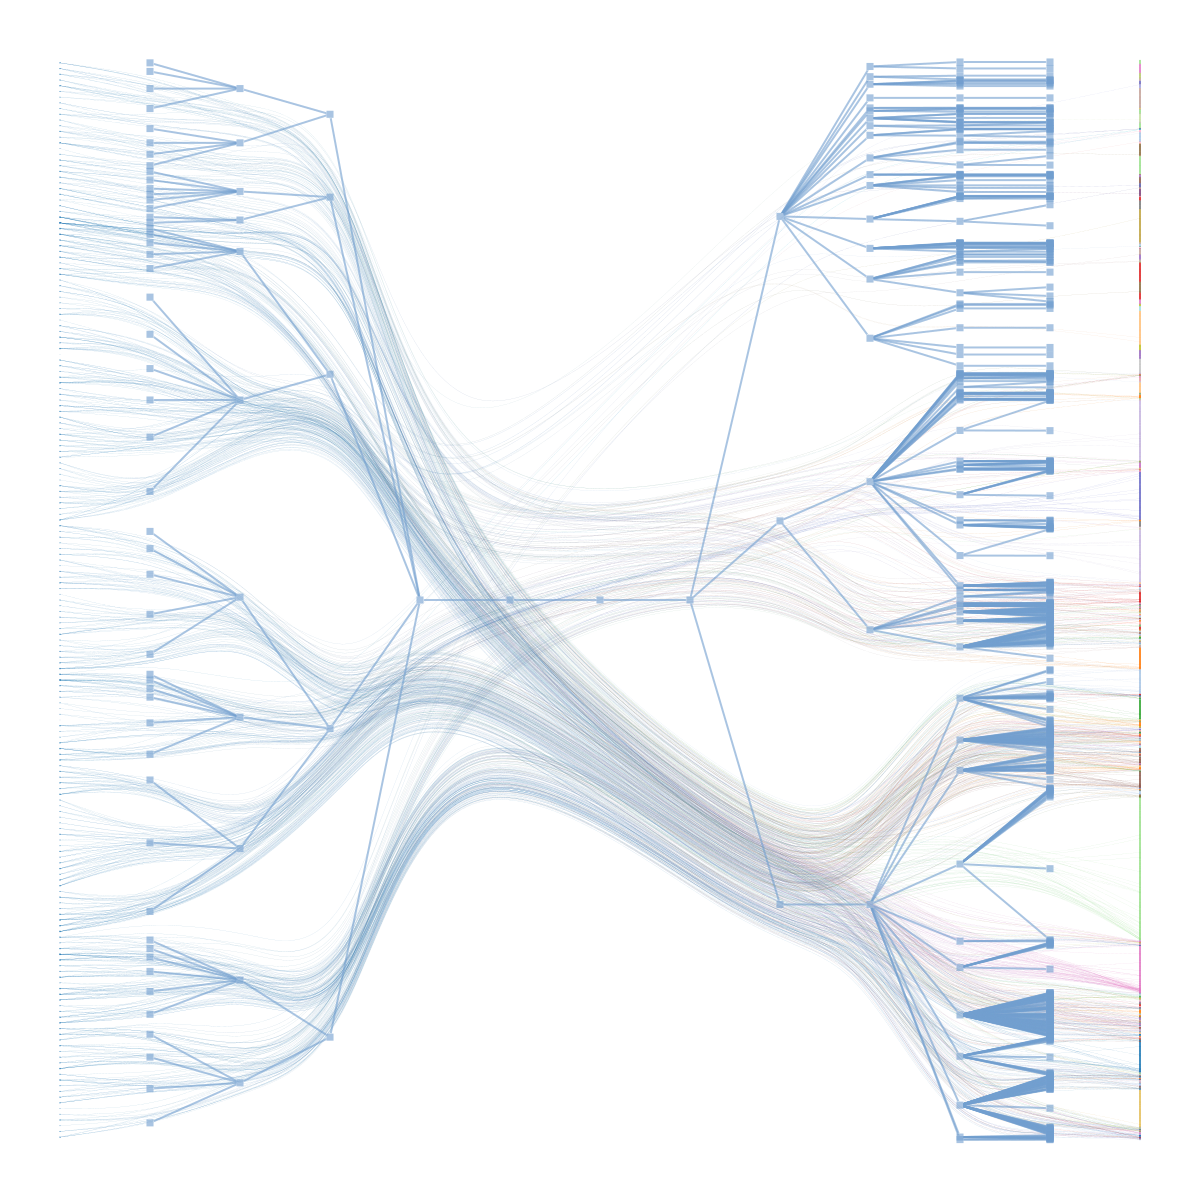

In [16]:
model.plot()

In [21]:
model.clusters(l=0)

{0: [],
 1: [],
 2: [],
 3: [],
 4: [],
 5: [],
 6: [],
 7: [],
 8: [],
 9: [],
 10: [],
 11: [],
 12: [],
 13: [],
 14: [],
 15: [],
 16: [],
 17: [],
 18: [],
 19: [],
 20: [],
 21: [],
 22: [],
 23: [],
 24: [],
 25: [],
 26: [],
 27: [],
 28: [],
 29: [],
 30: [],
 31: [],
 32: [],
 33: [],
 34: [],
 35: [],
 36: [],
 37: [],
 38: [],
 39: [],
 40: [],
 41: [],
 42: [],
 43: [],
 44: [],
 45: [],
 46: [],
 47: [],
 48: [],
 49: [],
 50: []}